In [535]:
!pip install yfinance --quiet

In [536]:
import yfinance as yf

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from pmdarima import auto_arima



In [537]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [538]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

## Данные по акциям

В работе мы будем анализировать дневные цены закрытия двух акций:

1. **LVMH Moët Hennessy Louis Vuitton SE**.
2. **NVIDIA Corporation**.

Исторические данные загружены с сайта Yahoo Finance за период 
с 01.01.2015 по 28.11.2025 и сохранены в файлы 
`lvmh_mcpa_daily.csv` и `nvda_daily.csv`.

Далее выполним предобработку данных и разделим выборки на train и test
в соответствии с условием задания (последние 10 наблюдений — тестовая выборка).



In [539]:
start_date = "2021-01-01"
end_date = "2025-11-30"

# LVMH
#lvmh_raw = yf.download("MC.PA", start=start_date, end=end_date, interval="1d")
#lvmh_raw.to_csv("lvmh_mcpa_daily.csv")

# NVIDIA
#nvda_raw = yf.download("NVDA", start=start_date, end=end_date, interval="1d")
#nvda_raw.to_csv("nvda_daily.csv")


Немного предобработки.

In [540]:
lvmh = pd.read_csv("lvmh_mcpa_daily_2.csv", sep = ';', parse_dates=["Date"])
nvda = pd.read_csv("nvda_daily_2.csv", sep = ';', parse_dates=["Date"])

lvmh = lvmh.sort_values("Date").set_index("Date")
nvda = nvda.sort_values("Date").set_index("Date")

# фильтруем период с 2021-01-01 
model_start = "2021-01-01"
lvmh = lvmh.loc[model_start:]
nvda = nvda.loc[model_start:]

# оставляем только цену закрытия и называем её y
lvmh = lvmh[["Close"]].rename(columns={"Close": "y"})
nvda = nvda[["Close"]].rename(columns={"Close": "y"})

lvmh.head()

,y
Date,
2021-01-04,469.362305
2021-01-05,463.954742
2021-01-06,460.380157
2021-01-07,472.295227
2021-01-08,481.460632


In [541]:
nvda.head()

,y
Date,
2021-01-04,13.077455
2021-01-05,13.367903
2021-01-06,12.579825
2021-01-07,13.307320
2021-01-08,13.240256


In [542]:
# График 1 — LVMH
fig_lvmh = px.line(
    lvmh,
    x=lvmh.index,
    y=lvmh['y'],
    title="LVMH – daily closing prices"
)

fig_lvmh.update_layout(template='plotly_white', width=800, height=500)
fig_lvmh.update_xaxes(title_text="date")
fig_lvmh.update_yaxes(title_text="closing price")
fig_lvmh.show()

# График 2 — NVIDIA
fig_nvda = px.line(
    nvda,
    x=nvda.index,
    y=nvda['y'],
    title="NVIDIA – daily closing prices"
)

fig_nvda.update_layout(template='plotly_white', width=800, height=500)
fig_nvda.update_xaxes(title_text="date")
fig_nvda.update_yaxes(title_text="closing price")
fig_nvda.show()


LVMH:

- Цена колеблется в диапазоне ~450–850 без устойчивого долгосрочного тренда

- Видны несколько среднесрочных волн роста и падения (цикличность), но не строгая сезонность

- Размах колебаний остаётся примерно одинаковым -> дисперсия стабильна, структура ближе к аддитивной

NVIDIA:

- Наблюдается ярко выраженный восходящий тренд: цена растёт с ~20 до ~200

- По мере роста уровня увеличивается и амплитуда колебаний -> волатильность растёт вместе с ценой

- Форма указывает на мультипликативную структуру

Разделение на train / test (последние 10 наблюдений)

In [543]:
h = 10  # размер тестовой выборки

# LVMH
lvmh_train = lvmh.iloc[:-h].copy()
lvmh_test  = lvmh.iloc[-h:].copy()

# NVIDIA
nvda_train = nvda.iloc[:-h].copy()
nvda_test  = nvda.iloc[-h:].copy()

print("LVMH:", len(lvmh_train), "train,", len(lvmh_test), "test")
print("NVDA:", len(nvda_train), "train,", len(nvda_test), "test")
lvmh_test.tail(), nvda_test.tail()


LVMH: 1250 train, 10 test
NVDA: 1223 train, 10 test


(                     y
 Date                  
 2025-11-24  616.379700
 2025-11-25  614.000244
 2025-11-26  620.048035
 2025-11-27  622.030945
 2025-11-28  630.061584,
                      y
 Date                  
 2025-11-21  178.880005
 2025-11-24  182.550003
 2025-11-25  177.820007
 2025-11-26  180.259995
 2025-11-28  177.000000)

Перестраиваем график для LVMH и NVIDIA (train + test)

In [544]:
fig = px.line(title="LVMH closing prices (daily)")

fig.add_scatter(
    x=lvmh_train.index,
    y=lvmh_train["y"],
    mode="lines",
    name="train",
    line=dict(color="blue")
)

fig.add_scatter(
    x=lvmh_test.index,
    y=lvmh_test["y"],
    mode="lines",
    name="test (forecast horizon)",
    line=dict(color="green")
)

fig.update_layout(template="plotly_white", width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()


In [545]:
fig = px.line(title="NVIDIA closing prices (daily)")

fig.add_scatter(
    x=nvda_train.index,
    y=nvda_train["y"],
    mode="lines",
    name="train",
    line=dict(color="blue")
)

fig.add_scatter(
    x=nvda_test.index,
    y=nvda_test["y"],
    mode="lines",
    name="test (forecast horizon)",
    line=dict(color="green")
)

fig.update_layout(template="plotly_white", width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()


## Этап 1. Анализ свойств временного ряда

На этом этапе анализирую свойства двух временных рядов (LVMH и NVIDIA) на обучающей выборке (train):

1. Проверяю стационарность с помощью двух тестов:
   * ADF (Augmented Dickey–Fuller) – H0: ряд нестационарен.
   * KPSS – H0: ряд стационарен.
2. Анализирую автокорреляцию:
   * тест Льюнга–Бокса на общую автокорреляцию,
   * графики ACF и PACF.
3. Если ряд нестационарный, привожу его к стационарному с помощью дифференцирования и повторяю тесты.


### 1.1. Проверка стационарности уровней цен (LVMH и NVIDIA)

Дальше запускаю ADF и KPSS на обучающей выборке `train` для каждого ряда.


ВЫВОД:

- ADF говорит: ряд нестационарен (p-value > 0.05, H0 “нестационарен” не отклоняем).

- KPSS говорит: ряд нестационарен (p-value < 0.05, отклоняем H0 “стационарен”).

То есть оба теста согласуются, что уровень цены LVMH нестационарен (есть тренд/единичный корень).

In [546]:
alpha = 0.05  # уровень значимости

print("LVMH (уровень цены, train)\n")
adf_test(lvmh_train["y"])
kpss_test(lvmh_train["y"])

LVMH (уровень цены, train)

Results of Dickey-Fuller Test:
Test Statistic                   -2.411668
p-value                           0.138470
#Lags Used                        0.000000
Number of Observations Used    1249.000000
Critical Value (1%)              -3.435596
Critical Value (5%)              -2.863857
Critical Value (10%)             -2.568004
dtype: float64
Results of KPSS Test:
Test Statistic            0.96749
p-value                   0.01000
Lags Used                20.00000
Critical Value (10%)      0.34700
Critical Value (5%)       0.46300
Critical Value (2.5%)     0.57400
Critical Value (1%)       0.73900
dtype: float64


ВЫВОД:

- ADF p-value = 0.99 — это очень сильное подтверждение нестационарности.
- KPSS отклоняет гипотезу стационарности.

In [547]:
print("\nNVIDIA (уровень цены, train)\n")
adf_test(nvda_train["y"])
kpss_test(nvda_train["y"])


NVIDIA (уровень цены, train)

Results of Dickey-Fuller Test:
Test Statistic                    0.684724
p-value                           0.989528
#Lags Used                       22.000000
Number of Observations Used    1200.000000
Critical Value (1%)              -3.435811
Critical Value (5%)              -2.863952
Critical Value (10%)             -2.568054
dtype: float64
Results of KPSS Test:
Test Statistic            5.071116
p-value                   0.010000
Lags Used                20.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


Уровни цен LVMH и NVIDIA нестационарны. Это ожидаемо для финансовых временных рядов с выраженным трендом. Для построения моделей прогнозирования необходимо сначала привести ряды к стационарному виду, например, с помощью дифференцирования.

### Шаг 1.2: дифференцирование и повторные тесты

In [548]:
# первая разность уровня цены на train-части
lvmh_diff = lvmh_train["y"].diff().dropna()

print("LVMH (первая разность, train)\n")
adf_test(lvmh_diff)
kpss_test(lvmh_diff)



LVMH (первая разность, train)

Results of Dickey-Fuller Test:
Test Statistic                  -36.246577
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    1248.000000
Critical Value (1%)              -3.435601
Critical Value (5%)              -2.863859
Critical Value (10%)             -2.568004
dtype: float64
Results of KPSS Test:
Test Statistic           0.121823
p-value                  0.100000
Lags Used                6.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


In [549]:
nvda_diff = nvda_train["y"].diff().dropna()

print("\nNVIDIA (первая разность, train)\n")
adf_test(nvda_diff)
kpss_test(nvda_diff)


NVIDIA (первая разность, train)

Results of Dickey-Fuller Test:
Test Statistic                -6.506014e+00
p-value                        1.130725e-08
#Lags Used                     2.100000e+01
Number of Observations Used    1.200000e+03
Critical Value (1%)           -3.435811e+00
Critical Value (5%)           -2.863952e+00
Critical Value (10%)          -2.568054e+00
dtype: float64
Results of KPSS Test:
Test Statistic            0.311316
p-value                   0.100000
Lags Used                11.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


### Вывод по стационарности

Для уровней цен LVMH и NVIDIA ADF-тест не отклоняет нулевую гипотезу
(ряд нестационарен), а KPSS-тест, наоборот, отклоняет гипотезу стационарности.
Оба теста согласуются в том, что уровни цен акций LVMH и NVIDIA являются
нестационарными.

После применения первой разности для обоих рядов:

- ADF-тест даёт p-value < 0.05 и позволяет отклонить гипотезу о нестационарности;
- KPSS-тест даёт p-value > 0.05 и не отвергает гипотезу стационарности.

Следовательно, ряды первых разностей цен LVMH и NVIDIA можно считать
стационарными. В дальнейших моделях использую спецификацию ARIMA с порядком
дифференцирования d = 1 для обеих акций.


### Шаг 1.3: ACF, PACF и Ljung–Box для стационарных рядов

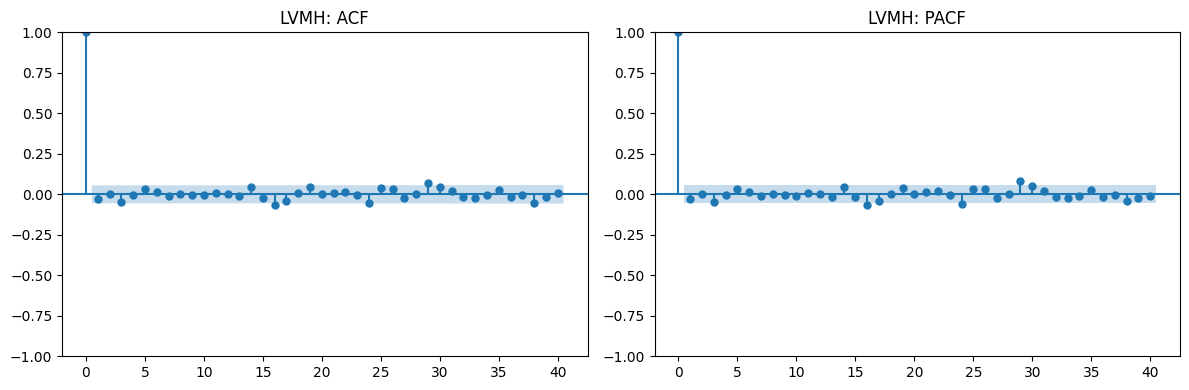

In [550]:
lags = 40  

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(lvmh_diff, lags=lags, ax=axes[0])
plot_pacf(lvmh_diff, lags=lags, ax=axes[1])
axes[0].set_title("LVMH: ACF")
axes[1].set_title("LVMH: PACF")
plt.tight_layout()
plt.show()


In [551]:
lb_lvmh = acorr_ljungbox(lvmh_diff, lags=[1,2,3,4,5,6,7,8,9,10], return_df=True)
lb_lvmh


,lb_stat,lb_pvalue
1,0.872488,0.350267
2,0.880528,0.643866
3,3.604895,0.307410
4,3.616469,0.460391
5,4.785961,0.442556
6,4.965065,0.548302
7,5.135685,0.643409
8,5.135698,0.742979
9,5.180345,0.818312
10,5.230282,0.875274


### Анализ автокорреляции для LVMH

Для стационарного ряда первых разностей цены LVMH были построены функции
ACF и PACF на 40 лагов, а также выполнен тест Льюнга–Бокса.

- На графиках ACF и PACF все значения, кроме лага 0, лежат внутри доверительных
  интервалов. Это означает отсутствие выраженной линейной зависимости между
  наблюдениями на различных лагах.
- В таблице теста Льюнга–Бокса для лагов 1–10 все p-value существенно больше
  0.05, поэтому нулевая гипотеза об отсутствии автокорреляции не отвергается.

Таким образом, после первой разности ряд LVMH можно считать стационарным
и близким к белому шуму. Это соответствует спецификации модели типа ARIMA
с порядком дифференцирования d = 1.


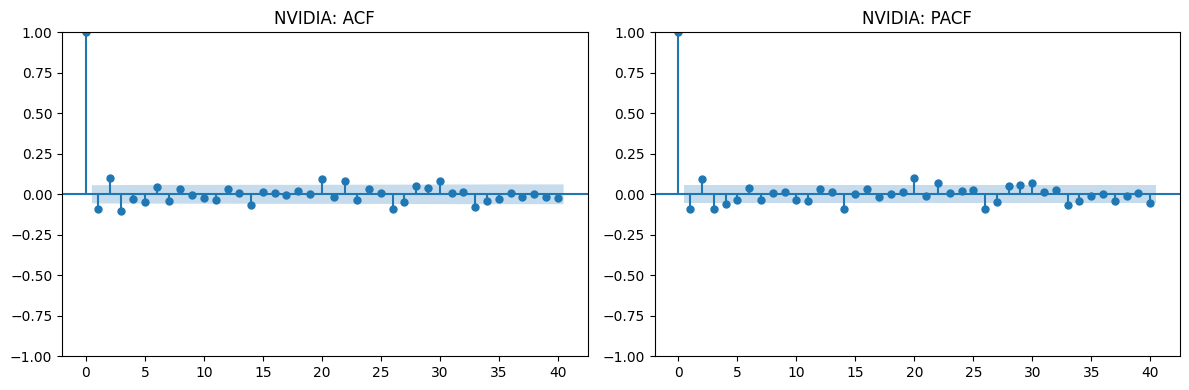

In [552]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(nvda_diff, lags=lags, ax=axes[0])
plot_pacf(nvda_diff, lags=lags, ax=axes[1])
axes[0].set_title("NVIDIA: ACF")
axes[1].set_title("NVIDIA: PACF")
plt.tight_layout()
plt.show()


In [553]:
lb_nvda = acorr_ljungbox(nvda_diff, lags=[1,2,3,4,5,6,7,8,9,10], return_df=True)
lb_nvda


,lb_stat,lb_pvalue
1,9.705718,1.836955e-03
2,22.627362,1.220480e-05
3,36.217790,6.735002e-08
4,37.475730,1.437305e-07
5,39.919742,1.550066e-07
6,42.283349,1.616454e-07
7,44.344048,1.833079e-07
8,45.711517,2.696781e-07
9,45.714483,6.803310e-07
10,46.534126,1.147505e-06


### Анализ автокорреляции для NVIDIA

Для стационарного ряда первых разностей цены NVIDIA были построены функции
ACF и PACF на 40 лагов и выполнен тест Льюнга–Бокса.

Визуально на ACF и PACF большинство значений лежит в пределах доверительных
интервалов, однако отдельные лаги приближаются к их границам, поэтому только
по коррелограммам сложно однозначно судить об отсутствии автокорреляции.

Результаты теста Льюнга–Бокса для лагов 1–10 показывают очень малые значения
p-value (все значительно меньше 0.05). Это позволяет отвергнуть нулевую
гипотезу об отсутствии автокорреляции. Следовательно, стационарный ряд
первых разностей NVIDIA не является белым шумом и содержит AR/MA-структуру,
которую необходимо моделировать с помощью ARIMA(p, 1, q) с ненулевыми
параметрами p и/или q.


### Итог Этапа 1: анализ стационарности и автокорреляции

1. **Стационарность уровней цен.**  
   Для уровней дневных цен LVMH и NVIDIA на обучающей выборке были проведены
   ADF- и KPSS-тесты. ADF-тест не отклоняет нулевую гипотезу о наличии
   единичного корня (p-value > 0.05), а KPSS-тест, наоборот, отклоняет
   гипотезу стационарности (p-value < 0.05). Оба теста согласуются в том,
   что уровни цен акций LVMH и NVIDIA являются нестационарными.

2. **Приведение к стационарности.**  
   Для приведения рядов к стационарности использована первая разность. После дифференцирования ADF-тест даёт
   p-value < 0.05, а KPSS-тест — p-value > 0.05 для обоих инструментов.
   Это означает, что ряды первых разностей цен LVMH и NVIDIA можно считать
   стационарными. В дальнейших моделях использую спецификацию ARIMA с
   порядком дифференцирования \(d = 1\).

3. **Автокорреляция стационарных рядов.**  
   Для стационарных рядов первых разностей построены ACF и PACF и выполнен
   тест Льюнга–Бокса.
   - Для LVMH большинство значений ACF/PACF лежит внутри доверительных
     интервалов, а тест Льюнга–Бокса для лагов 1–10 даёт p-value > 0.05.
     Это означает, что автокорреляция статистически незначима и ряд первых
     разностей близок к белому шуму. 
   - Для NVIDIA ACF/PACF визуально выглядят шумно, однако тест Льюнга–Бокса
     показывает очень малые p-value для лагов 1–10 (существенно меньше 0.05),
     поэтому нулевая гипотеза об отсутствии автокорреляции отвергается.
     Стационарный ряд первых разностей NVIDIA остаётся автокоррелированным,
     что указывает на наличие AR/MA-структуры и необходимость использовать
     ARIMA(p, 1, q) с ненулевыми параметрами p и/или q.


## Этап 2. Построение базовой модели ARIMA



### 2.1 LVMH: ручной перебор ARIMA(p,1,q)

In [554]:
import warnings
warnings.filterwarnings("ignore")

d = 1   # по результатам тестов стационарности

best_lvmh = []

for p in range(0, 6):      # p = 0.5
    for q in range(0, 6):  # q = 0.5
        try:
            model = ARIMA(y_lvmh_train, order=(p, d, q)).fit()
            best_lvmh.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": model.aic,
                "BIC": model.bic
            })
        except Exception:
            continue

results_lvmh = (
    pd.DataFrame(best_lvmh)
    .sort_values("AIC")
    .reset_index(drop=True)
)

results_lvmh.head(10)


,p,d,q,AIC,BIC
0,0,1,0,9639.243925,9644.374024
1,3,1,2,9639.389357,9670.169948
2,2,1,3,9639.449681,9670.230273
3,1,1,0,9640.382577,9650.642774
4,0,1,1,9640.384482,9650.644679
5,2,1,4,9641.242519,9677.153208
6,3,1,0,9641.686707,9662.207101
7,0,1,3,9641.704004,9662.224398
8,1,1,1,9641.929522,9657.319818
9,4,1,4,9642.220438,9688.391324


In [555]:
p_lvmh_best = int(results_lvmh.loc[0, "p"])
q_lvmh_best = int(results_lvmh.loc[0, "q"])

arima_lvmh_manual = ARIMA(
    y_lvmh_train,
    order=(p_lvmh_best, d, q_lvmh_best)
).fit()

print(arima_lvmh_manual.summary())
print("Ручной выбор порядка ARIMA для LVMH:", arima_lvmh_manual.model_orders)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1250
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -4818.622
Date:                Sun, 07 Dec 2025   AIC                           9639.244
Time:                        18:30:53   BIC                           9644.374
Sample:                             0   HQIC                          9641.173
                               - 1250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       131.3810      2.814     46.680      0.000     125.865     136.897
Ljung-Box (L1) (Q):                   0.87   Jarque-Bera (JB):              1331.25
Prob(Q):                              0.35   Pr

In [556]:
# in-sample на train
lvmh_manual_fitted = arima_lvmh_manual.predict(
    start=y_lvmh_train.index[0],
    end=y_lvmh_train.index[-1]
)
lvmh_manual_fitted = pd.Series(
    lvmh_manual_fitted,
    index=y_lvmh_train.index,
    name="lvmh_manual_fitted"
)

# out-of-sample на 10 шагов
forecast_res_lvmh_manual = arima_lvmh_manual.get_forecast(steps=len(y_lvmh_test))
lvmh_manual_forecast = forecast_res_lvmh_manual.predicted_mean
lvmh_manual_forecast.index = y_lvmh_test.index
lvmh_manual_forecast.name = "lvmh_manual_forecast"

lvmh_manual_fitted.head(), lvmh_manual_forecast.head()


(Date
 2021-01-04      0.000000
 2021-01-05    469.362305
 2021-01-06    463.954742
 2021-01-07    460.380157
 2021-01-08    472.295227
 Name: lvmh_manual_fitted, dtype: float64,
 Date
 2025-11-17    631.548767
 2025-11-18    631.548767
 2025-11-19    631.548767
 2025-11-20    631.548767
 2025-11-21    631.548767
 Name: lvmh_manual_forecast, dtype: float64)

### Вывод по ручной выбор порядка ARIMA для LVMH.
Перебрала модели ARIMA(p,1,q) для p,q и ранжировала их по AIC/BIC. Лучшими по обоим критериям оказались модели с порядком (p,d,q) = (0,1,0) (AIC = 9639.24, BIC = 9644.37).
Оценка параметров ARIMA(0,1,0) показывает, что модель представляет собой случайное блуждание без дрейфа: первые разности цен LVMH описываются белым шумом с дисперсией 
≈
131.4

### 2.2 Авто выбор порядка ARIMA для LVMH.
Для LVMH на Этапе 1 было показано, что:

- уровни цен нестационарны (ADF и KPSS);
- первая разность стационарна и не показывает значимой автокорреляции.

Поэтому в качестве базовой модели использую ARIMA с порядком дифференцирования
d = 1. Параметры p и q подбираю с помощью `auto_arima` по критерию AIC, BIC.


In [557]:
# горизонт прогноза = размер тестовой выборки
h_lvmh = len(lvmh_test)

# auto_arima для LVMH
arima_lvmh = auto_arima(
    lvmh_train["y"],
    d=1,                      # d = 1 по результатам ADF/KPSS
    start_p=0, start_q=0,
    max_p=5, max_q=5,         # разумные пределы для AR и MA
    seasonal=False,           # дневные цены акций, сезонность не моделируем
    stepwise=True,            # stepwise-поиск 
    information_criterion="aic",
    trace=True,               # вывод перебираемых моделей 
    error_action="ignore",
    suppress_warnings=True
)

print(arima_lvmh.summary())
print("Выбранный порядок ARIMA для LVMH:", arima_lvmh.order)



Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9641.084, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9642.213, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9642.215, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9639.244, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9643.764, Time=0.11 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.186 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1250
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4818.622
Date:                Sun, 07 Dec 2025   AIC                           9639.244
Time:                        18:30:54   BIC                           9644.374
Sample:                             0   HQIC                          9641.173
                               - 1250                                       

Полученный результат согласуется с ручным подбором параметров, который также выбирает ARIMA(0,1,0) как оптимальную модель для LVMH.

### 2.3 Выбор базовой модели ARIMA для LVMH

Для ряда дневных цен акций LVMH (MC.PA) на обучающей выборке была
подобрана модель ARIMA с помощью функции `auto_arima`.

Из Этапа 1 известно, что уровни цен нестационарны, а первая разность
стационарна, поэтому порядок дифференцирования был зафиксирован как d = 1.
Параметры p и q подбирались по критерию AIC.

Результат подбора:

Модель ARIMA(0, 1, 0) без константы соответствует случайному блужданию:
следующее значение цены равно предыдущему плюс случайный шок. Это согласуется
с результатами Этапа 1: первая разность цен LVMH ведёт себя как белый шум.

Диагностика остатков показывает, что тест Льюнга–Бокса для лага 1
даёт p-value ≈ 0.35 (> 0.05), то есть остатки модели не имеют значимой
автокорреляции. Таким образом, ARIMA(0, 1, 0) можно считать адекватной
базовой моделью для ряда LVMH.


In [558]:
lvmh_forecast_values = arima_lvmh.predict(n_periods=h_lvmh)

print("Тип и длина:", type(lvmh_forecast_values), len(lvmh_forecast_values))
print("Первые предсказания:", lvmh_forecast_values)


Тип и длина: <class 'pandas.core.series.Series'> 10
Первые предсказания: 1250    631.548767
1251    631.548767
1252    631.548767
1253    631.548767
1254    631.548767
1255    631.548767
1256    631.548767
1257    631.548767
1258    631.548767
1259    631.548767
dtype: float64


In [559]:
# in-sample прогноз
lvmh_fitted = arima_lvmh.predict_in_sample()
lvmh_fitted = pd.Series(lvmh_fitted, index=lvmh_train.index, name="fitted")

# out-of-sample прогноз
h_lvmh = len(lvmh_test)
lvmh_forecast_values = arima_lvmh.predict(n_periods=h_lvmh)

lvmh_forecast = pd.Series(
    lvmh_forecast_values.values,      
    index=lvmh_test.index,
    name="forecast"
)

lvmh_fitted.head(), lvmh_forecast.head()



(Date
 2021-01-04      0.000000
 2021-01-05    469.362305
 2021-01-06    463.954742
 2021-01-07    460.380157
 2021-01-08    472.295227
 Name: fitted, dtype: float64,
 Date
 2025-11-17    631.548767
 2025-11-18    631.548767
 2025-11-19    631.548767
 2025-11-20    631.548767
 2025-11-21    631.548767
 Name: forecast, dtype: float64)

По результатам ADF/KPSS принимаю d=1, поэтому в auto_arima фиксирую d=1, а порядок (p, q) подбираю автоматически по AIC. Лучшая модель — ARIMA(0,1,0), т.е. random walk.

In [560]:

fig = px.line(title="LVMH: фактические значения и прогноз ARIMA")

fig.add_scatter(
    x=lvmh_train.index,
    y=lvmh_train["y"],
    mode="lines",
    name="LVMH train (fact)"
)

fig.add_scatter(
    x=lvmh_test.index,
    y=lvmh_test["y"],
    mode="lines",
    name="LVMH test (fact)"
)

fig.add_scatter(
    x=lvmh_forecast.index,
    y=lvmh_forecast,
    mode="lines",
    name="LVMH ARIMA forecast"
)

fig.update_layout(template="plotly_white", width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()


Для LVMH после проверки стационарности уровня и первой разности построила базовую модель ARIMA.
С помощью auto_arima на обучающей выборке (все наблюдения, кроме последних 10 дней) был выбран порядок ARIMA(0,1,0) по критерию AIC.
Эта модель соответствует случайному блужданию без дрейфа, поэтому прогноз на 10 шагов вперёд представляет собой горизонтальную линию на уровне последнего значения train.
In-sample прогноз хорошо описывает динамику разностей, а out-of-sample прогноз даёт разумную точку отсчёта для дальнейшего сравнения с более сложными моделями (ARIMAX).

### Этап 2. Построение базовой модели ARIMA для NVIDIA

### 2.4 Ручной подбор параметром для NVIDIA.

In [561]:
d = 1  # по тестам стационарности тоже одна разность

best_nvda = []

for p in range(0, 6):
    for q in range(0, 6):
        try:
            model = ARIMA(y_nvda_train, order=(p, d, q)).fit()
            best_nvda.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": model.aic,
                "BIC": model.bic
            })
        except Exception:
            continue

results_nvda = (
    pd.DataFrame(best_nvda)
    .sort_values("AIC")
    .reset_index(drop=True)
)

results_nvda.head(10)


,p,d,q,AIC,BIC
0,2,1,5,5699.646795,5740.512748
1,4,1,5,5701.612972,5752.695413
2,5,1,5,5702.174856,5758.365542
3,3,1,5,5703.627663,5749.601860
4,4,1,4,5705.264480,5751.238677
5,5,1,4,5708.690578,5759.773019
6,1,1,3,5709.160028,5734.701248
7,0,1,4,5709.244729,5734.785949
8,3,1,1,5709.337326,5734.878547
9,4,1,0,5709.366865,5734.908085


In [562]:
p_nvda_best = int(results_nvda.loc[0, "p"])
q_nvda_best = int(results_nvda.loc[0, "q"])

arima_nvda_manual = ARIMA(
    y_nvda_train,
    order=(p_nvda_best, d, q_nvda_best)
).fit()

print(arima_nvda_manual.summary())
print("Ручной выбор порядка ARIMA для NVIDIA:", arima_nvda_manual.model_orders)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1223
Model:                 ARIMA(2, 1, 5)   Log Likelihood               -2841.823
Date:                Sun, 07 Dec 2025   AIC                           5699.647
Time:                        18:31:01   BIC                           5740.513
Sample:                             0   HQIC                          5715.027
                               - 1223                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7042      0.022    -31.591      0.000      -0.748      -0.660
ar.L2         -0.9377      0.020    -47.935      0.000      -0.976      -0.899
ma.L1          0.6357      0.026     24.604      0.0

In [563]:
# in-sample на train
nvda_manual_fitted = arima_nvda_manual.predict(
    start=y_nvda_train.index[0],
    end=y_nvda_train.index[-1]
)
nvda_manual_fitted = pd.Series(
    nvda_manual_fitted,
    index=y_nvda_train.index,
    name="nvda_manual_fitted"
)

# out-of-sample на 10 шагов
forecast_res_nvda_manual = arima_nvda_manual.get_forecast(steps=len(y_nvda_test))
nvda_manual_forecast = forecast_res_nvda_manual.predicted_mean
nvda_manual_forecast.index = y_nvda_test.index
nvda_manual_forecast.name = "nvda_manual_forecast"

nvda_manual_fitted.head(), nvda_manual_forecast.head()


(Date
 2021-01-04     0.000000
 2021-01-05    13.077448
 2021-01-06    13.343382
 2021-01-07    12.666747
 2021-01-08    13.166900
 Name: nvda_manual_fitted, dtype: float64,
 Date
 2025-11-14    187.263609
 2025-11-17    187.128215
 2025-11-18    187.959647
 2025-11-19    187.657045
 2025-11-20    187.654162
 Name: nvda_manual_forecast, dtype: float64)

### Вывод по ручному подбору ARIMA-порядков для NVIDIA.
По перебору моделей ARIMA(p,1,q) с p,q минимальное значение информационного критерия AIC (5699.65) достигается для модели ARIMA(2,1,5). Эта же модель имеет минимальный BIC среди рассмотренных альтернатив, поэтому далее используем именно её как ручной вариант.

В оценённой ARIMA(2,1,5) все коэффициенты AR и практически все коэффициенты MA статистически значимы (p-value < 0.05), за исключением ma.L4, у которого p-value ≈ 0.67. Формально этот лаг можно было бы исключить и переоценить модель, однако в рамках работы мы оставляем полный вариант и фиксируем данный факт в интерпретации.

### 2.5 Авто подбор порядка ARIMA для NVIDIA.

Для NVIDIA после проверки стационарности исходного уровня и первой разности подбирала порядки модели ARIMA по auto_arima.
На обучающей выборке (все наблюдения, кроме последних 10 дней) по критерию AIC была выбрана модель ARIMA(3,1,1).
В отличие от LVMH, здесь первая разность демонстрировала заметную автокорреляцию, поэтому в оптимальной модели появились ненулевые AR- и MA-компоненты (p=3, q=1).
На основе полученной модели построила:

in-sample прогноз на обучающей выборке (predict_in_sample),

out-of-sample прогноз на 10 дней вперёд (predict(n_periods=10)), который сравнивается с фактическими значениями тестовой выборки.

In [564]:
# горизонт прогноза = размер тестовой выборки NVIDIA (10 наблюдений)
h_nvda = len(nvda_test)

# auto_arima для NVIDIA
arima_nvda_auto = auto_arima(
    nvda_train["y"],
    d=1,                      # d = 1 по результатам ADF/KPSS (Этап 1)
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    stepwise=True,
    information_criterion="aic",
    trace=True
)

print(arima_nvda_auto.summary())
print("Выбранный порядок ARIMA для NVIDIA:", arima_nvda_auto.order)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5733.324, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5725.549, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5727.068, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5735.202, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=5716.299, Time=0.03 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=5708.181, Time=0.04 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=5706.236, Time=0.05 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=5706.749, Time=0.07 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=5707.518, Time=0.12 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=5705.858, Time=0.10 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5712.811, Time=0.12 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=5707.301, Time=0.15 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=5714.667, Time=0.14 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=5709.299, Time=0.29 sec
 ARIMA(3,1,1)(0,0,0)[0]          

Выбрана ARIMA(3,1,1), d=1 из тестов, наличие автокорреляции в первой разности оправдывает ненулевые p и q.

### 2.6 Выбор базовой модели ARIMA для NVIDIA

Для ряда NVIDIA сравнили результаты ручного подбора и auto_arima:

- Ручной перебор ARIMA(p,1,q):
  - лучшая по AIC модель — **ARIMA(2,1,5)** с AIC = 5699.65, BIC = 5740.51;
- auto_arima:
  - выбрана модель **ARIMA(3,1,1)** с AIC = 5705.86, BIC = 5736.51.

Таким образом:

- по **AIC** более предпочтительна модель ARIMA(2,1,5);
- по **BIC** более предпочтительна модель ARIMA(3,1,1), так как она существенно проще
  (меньше параметров AR/MA) и сильнее штрафуется BIC за сложность.

Обе модели дают очень похожие прогнозы на тестовых 10 точках и хорошо снимают автокорреляцию в остатках
(p-value теста Льюнга–Бокса >> 0.05 для лагов 1, 5, 10).

В качестве основного критерия
для ARIMA используется именно **AIC**, в качестве финальной модели для NVIDIA я буду
использовать модель **ARIMA(2,1,5)** (лучшую по AIC), а модель ARIMA(3,1,1) оставляю как
результат auto_arima и пример более простой альтернативы.


In [565]:
h_nvda = len(y_nvda_test)

# in-sample прогноз (на обучающей выборке)
nvda_fitted = arima_nvda_manual.predict(
    start=y_nvda_train.index[0],
    end=y_nvda_train.index[-1]
)
nvda_fitted = pd.Series(nvda_fitted, index=y_nvda_train.index, name="fitted")

# out-of-sample прогноз на 10 будущих периодов
nvda_forecast_values = arima_nvda_manual.get_forecast(steps=h_nvda)
nvda_forecast = pd.Series(
    nvda_forecast_values.predicted_mean.values,
    index=y_nvda_test.index,
    name="forecast"
)

nvda_fitted.head(), nvda_forecast.head()


(Date
 2021-01-04     0.000000
 2021-01-05    13.077448
 2021-01-06    13.343382
 2021-01-07    12.666747
 2021-01-08    13.166900
 Name: fitted, dtype: float64,
 Date
 2025-11-14    187.263609
 2025-11-17    187.128215
 2025-11-18    187.959647
 2025-11-19    187.657045
 2025-11-20    187.654162
 Name: forecast, dtype: float64)

In [582]:
fig = px.line(title="NVIDIA: фактические значения и прогноз ARIMA")

fig.add_scatter(
    x=nvda_train.index,
    y=nvda_train["y"],
    mode="lines",
    name="NVIDIA train (fact)"
)

fig.add_scatter(
    x=nvda_test.index,
    y=nvda_test["y"],
    mode="lines",
    name="NVIDIA test (fact)"
)

fig.add_scatter(
    x=nvda_forecast.index,
    y=nvda_forecast,
    mode="lines",
    name="NVIDIA ARIMA(2,1,5) forecast"
)

fig.update_layout(template="plotly_white", width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()


Для NVIDIA модель в целом описывает уровень,
но не идеально попадает в локальный нисходящий тренд последних дней.

## Этап 3. Выбор Модели ARMAX/ARIMAX

### 3.1. LVMH: формируем регрессоры

In [567]:
# полный индекс дат по LVMH
idx_lvmh = lvmh.index

X_lvmh = pd.DataFrame(index=idx_lvmh)

#Непрерывный регрессор: простой линейный тренд по времени
#    (номер дня с начала выборки).
X_lvmh["trend"] = np.arange(len(idx_lvmh))

#Dummy: понедельник (эффект начала недели)
X_lvmh["is_monday"] = (idx_lvmh.weekday == 0).astype(int)

#Dummy: «предпраздничные месяцы» — ноябрь и декабрь
X_lvmh["is_holiday_month"] = idx_lvmh.month.isin([11, 12]).astype(int)

X_lvmh.head()


,trend,is_monday,is_holiday_month
Date,,,
2021-01-04,0,1,0
2021-01-05,1,0,0
2021-01-06,2,0,0
2021-01-07,3,0,0
2021-01-08,4,0,0


Для акции LVMH в качестве экзогенных переменных используются три регрессора:

- линейный временной тренд, для обеих акций на длинном горизонте есть восходящий тренд: бизнес растёт, рынок в целом рос последние годы 

- dummy переменная понедельника (is_monday) (эффект понедельника как начало недели)

- dummy переменная праздничных месяцев (is_holiday_month, ноябрь–декабрь). Для LVMH (люкс, ретейл) логично выделить ноябрь–декабрь как период повышенной активности (Black Friday, новогодние/рождественские продажи).

Эти регрессоры не зависят напрямую от целевой переменной (цены закрытия), отражают календарные эффекты и общий тренд.

In [568]:
# те же train/test по Y
y_lvmh_train = lvmh_train["y"]
y_lvmh_test  = lvmh_test["y"]

# регрессоры на train / test, режем по тем же индексам
X_lvmh_train = X_lvmh.loc[lvmh_train.index]
X_lvmh_test  = X_lvmh.loc[lvmh_test.index]

y_lvmh_train.shape, X_lvmh_train.shape, y_lvmh_test.shape, X_lvmh_test.shape


((1250,), (1250, 3), (10,), (10, 3))

### 3.2. NVIDIA: формируем регрессоры

In [569]:
idx_nvda = nvda.index

X_nvda = pd.DataFrame(index=idx_nvda)

#Непрерывный регрессор: линейный тренд
X_nvda["trend"] = np.arange(len(idx_nvda))

#Dummy: пятница (эффект конца недели)
X_nvda["is_friday"] = (idx_nvda.weekday == 4).astype(int)

#Dummy: период AI-бума после 2023-01-01
X_nvda["is_post_ai_boom"] = (idx_nvda >= "2023-01-01").astype(int)

X_nvda.head()


,trend,is_friday,is_post_ai_boom
Date,,,
2021-01-04,0,0,0
2021-01-05,1,0,0
2021-01-06,2,0,0
2021-01-07,3,0,0
2021-01-08,4,1,0


Для акции NVIDIA в качестве экзогенных факторов использую три переменные:

- временной тренд, использую временной тренд как непрерывный фактор, отражающий долгосрочный рост интереса к акциям компании и рынку ИИ в целом.

- dummy переменную пятницы (is_friday), позволяет уловить возможный эффект дня недели на динамику цен (фиксирование прибыли)

- dummy переменную периода AI-бума после 2023-01-01 (is_post_ai_boom). Эта переменная моделирует структурный сдвиг в уровне цен NVIDIA после начала активного роста рынка ИИ и резкого повышения спроса на GPU.

Эти регрессоры зависят только от календаря и дат, а не от самой цены акции.

In [570]:
y_nvda_train = nvda_train["y"]
y_nvda_test  = nvda_test["y"]

X_nvda_train = X_nvda.loc[nvda_train.index]
X_nvda_test  = X_nvda.loc[nvda_test.index]

y_nvda_train.shape, X_nvda_train.shape, y_nvda_test.shape, X_nvda_test.shape


((1223,), (1223, 3), (10,), (10, 3))

### 3.3. LVMH: ARIMAX с регрессорами

In [571]:
# горизонт прогноза = размер тестовой выборки (10 наблюдений)
h_lvmh = len(y_lvmh_test)

arimax_lvmh = auto_arima(
    y_lvmh_train,
    X=X_lvmh_train,
    d=1,                     # ряд нестационарен, используем одну разность
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    stepwise=True,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
)

print(arimax_lvmh.summary())
print("Выбранный порядок ARIMAX для LVMH:", arimax_lvmh.order)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9646.715, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9647.821, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9647.824, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9644.715, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9649.309, Time=0.19 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.408 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1250
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4818.357
Date:                Sun, 07 Dec 2025   AIC                           9644.715
Time:                        18:31:02   BIC                           9665.235
Sample:                             0   HQIC                          9652.429
                               - 1250                                       

Для акции LVMH построила модель ARIMAX(0,1,0) с тремя экзогенными регрессорами: временным трендом, дамми-переменной понедельника и дамми-переменной для праздничных месяцев (ноябрь–декабрь).

Однако все регрессоры оказались статистически незначимыми (p-value ≫ 0.05), а значение AIC у модели с регрессорами (9644.7) оказалось выше, чем у базовой модели ARIMA(0,1,0) без экзогенных переменных (9639.2).

Это означает, что добавление выбранных регрессоров не улучшает качество модели. Поэтому в качестве лучшей модели для LVMH я оставляю базовую ARIMA(0,1,0) без экзогенных переменных, а ARIMAX использую только как иллюстрацию того, что попытка добавить эти факторы не дала прироста качества.

### Прогноз ARIMAX для LVMH

In [572]:
# in-sample прогноз (train)
lvmh_arimax_fitted = arimax_lvmh.predict_in_sample(X=X_lvmh_train)

lvmh_arimax_fitted = pd.Series(
    lvmh_arimax_fitted.values,   # берём только значения
    index=y_lvmh_train.index,    
    name="fitted_arimax"
)

# out-of-sample прогноз (test, 10 точек)
lvmh_arimax_forecast_values = arimax_lvmh.predict(
    n_periods=h_lvmh,
    X=X_lvmh_test
)

lvmh_arimax_forecast = pd.Series(
    lvmh_arimax_forecast_values.values,  # только значения
    index=y_lvmh_test.index,             
    name="forecast_arimax"
)

lvmh_arimax_fitted.head(), lvmh_arimax_forecast.head()


(Date
 2021-01-04     -0.195197
 2021-01-05    469.685754
 2021-01-06    464.082994
 2021-01-07    460.508409
 2021-01-08    472.423479
 Name: fitted_arimax, dtype: float64,
 Date
 2025-11-17    631.481822
 2025-11-18    631.805271
 2025-11-19    631.933523
 2025-11-20    632.061774
 2025-11-21    632.190026
 Name: forecast_arimax, dtype: float64)

In [573]:

fig = px.line(title="LVMH: фактические значения и прогноз ARIMAX")

fig.add_scatter(x=y_lvmh_train.index, y=y_lvmh_train,
                mode="lines", name="LVMH train (fact)")
fig.add_scatter(x=y_lvmh_test.index,  y=y_lvmh_test,
                mode="lines", name="LVMH test (fact)")
fig.add_scatter(x=lvmh_arimax_forecast.index, y=lvmh_arimax_forecast,
                mode="lines", name="LVMH ARIMAX forecast")

fig.update_layout(template="plotly_white", width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()

### 3.4. NVIDIA: ARIMAX с регрессорами

In [574]:
# горизонт прогноза NVIDIA (10 наблюдений)
h_nvda = len(y_nvda_test)

arimax_nvda = auto_arima(
    y_nvda_train,
    X=X_nvda_train,
    d=1,                    # одна разность по результатам тестов
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    stepwise=True,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
)

print(arimax_nvda.summary())
print("Выбранный порядок ARIMAX для NVIDIA:", arimax_nvda.order)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5737.415, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5729.902, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5731.371, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5735.415, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=5720.837, Time=0.05 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=5712.987, Time=0.07 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=5711.046, Time=0.09 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=5711.333, Time=0.13 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=5712.237, Time=0.18 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=5710.579, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5717.431, Time=0.21 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=5711.982, Time=0.24 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=5719.330, Time=0.27 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=5713.975, Time=0.46 sec
 ARIMA(3,1,1)(0,0,0)[0]          

### Прогноз ARIMAX для NVIDIA

In [575]:
# in-sample прогноз (train)
nvda_arimax_fitted = arimax_nvda.predict_in_sample(X=X_nvda_train)
nvda_arimax_fitted = pd.Series(
    nvda_arimax_fitted,
    index=y_nvda_train.index,
    name="fitted_arimax"
)

# out-of-sample прогноз на 10 будущих периодов
nvda_arimax_forecast_values = arimax_nvda.predict(
    n_periods=h_nvda,
    X=X_nvda_test
)
nvda_arimax_forecast = pd.Series(
    nvda_arimax_forecast_values.values, # только значения
    index=y_nvda_test.index,
    name="forecast_arimax"
)

nvda_arimax_fitted.head(), nvda_arimax_forecast.head()


(Date
 2021-01-04     0.000000
 2021-01-05    13.221229
 2021-01-06    13.498692
 2021-01-07    12.812303
 2021-01-08    13.184777
 Name: fitted_arimax, dtype: float64,
 Date
 2025-11-14    187.660369
 2025-11-17    187.293960
 2025-11-18    188.263620
 2025-11-19    188.566625
 2025-11-20    188.973621
 Name: forecast_arimax, dtype: float64)

In [576]:
fig = px.line(title="NVIDIA: фактические значения и прогноз ARIMAX")

fig.add_scatter(
    x=y_nvda_train.index,
    y=y_nvda_train,
    mode="lines",
    name="NVIDIA train (fact)"
)

fig.add_scatter(
    x=y_nvda_test.index,
    y=y_nvda_test,
    mode="lines",
    name="NVIDIA test (fact)"
)

fig.add_scatter(
    x=nvda_arimax_forecast.index,
    y=nvda_arimax_forecast,
    mode="lines",
    name="NVIDIA ARIMAX forecast"
)

fig.update_layout(template="plotly_white", width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()


Прогноз ARIMAX остаётся ниже тестовых значений и идёт немного по другой траектории, но по масштабу ошибки плюс-минус то же самое, что и у ARIMA(3,1,1).

### Общий итог по Этапу 3
Для обоих активов (LVMH и NVIDIA) добавление регрессоров: 
- не улучшило значения AIC/BIC относительно базовых ARIMA-моделей;

- дало статистически незначимые коэффициенты по всем X;

- не привело к заметному повышению качества прогноза на 10-дневном горизонте.

Следовательно, в рамках выбранных регрессоров ARIMA-модели без внешних факторов оказываются предпочтительными, а ARIMAX-модели служат, прежде всего, для демонстрации методики включения экзогенных переменных в прогноз временных рядов.

## Этап 4. Оценка и Выбор Лучшей Модели

### 4.1 Диагностика остатков для LVMH

LVMH ARIMA: Ljung–Box p-values (lags 1, 5, 10)
     lb_stat  lb_pvalue
1   0.407894   0.523041
5   0.698371   0.983058
10  1.285015   0.999464


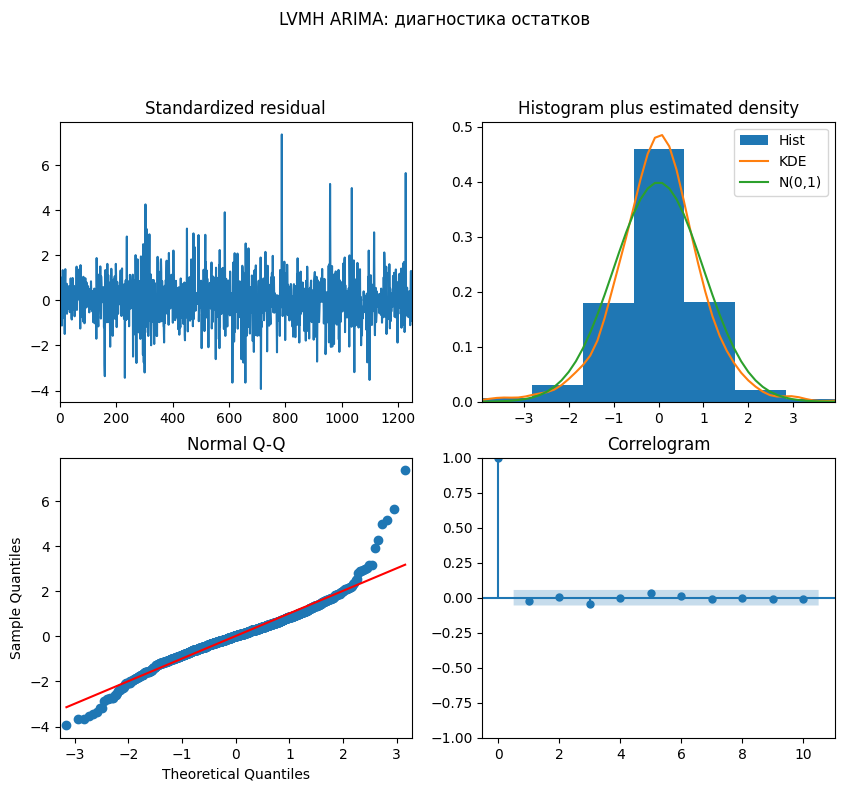

In [577]:
#Остатки ARIMA для LVMH

# arima_lvmh — модель ARIMA без регрессоров (из Этапа 2)
lvmh_resid_arima = pd.Series(
    arima_lvmh.arima_res_.resid,
    index=lvmh_train.index,
    name="resid_arima_lvmh"
)

print("LVMH ARIMA: Ljung–Box p-values (lags 1, 5, 10)")
print(
    acorr_ljungbox(
        lvmh_resid_arima.dropna(),
        lags=[1, 5, 10],
        return_df=True
    )
)

fig = arima_lvmh.plot_diagnostics(figsize=(10, 8))
fig.suptitle("LVMH ARIMA: диагностика остатков", y=1.02)
plt.show()



LVMH ARIMAX: Ljung–Box p-values (lags 1, 5, 10)
     lb_stat  lb_pvalue
1   0.425225   0.514341
5   0.718305   0.981949
10  1.318679   0.999398


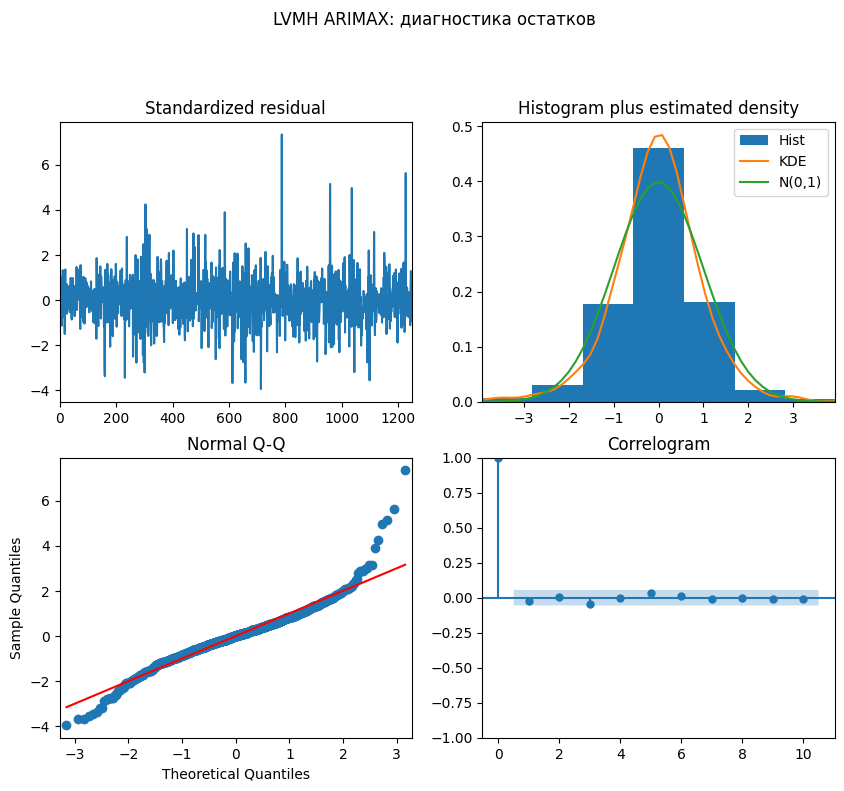

In [578]:
#Остатки ARIMAX для LVMH

# arimax_lvmh — модель с регрессорами (из Этапа 3)
lvmh_resid_arimax = pd.Series(
    arimax_lvmh.arima_res_.resid,
    index=y_lvmh_train.index,
    name="resid_arimax_lvmh"
)

print("LVMH ARIMAX: Ljung–Box p-values (lags 1, 5, 10)")
print(
    acorr_ljungbox(
        lvmh_resid_arimax.dropna(),
        lags=[1, 5, 10],
        return_df=True
    )
)

fig = arimax_lvmh.plot_diagnostics(figsize=(10, 8))
fig.suptitle("LVMH ARIMAX: диагностика остатков", y=1.02)
plt.show()

### 4.1. Вывод по диагностики остатков для LVMH

Для модели ARIMA(0,1,0) и модели ARIMAX с регрессорами были построены стандартные диагностические графики:

- колеблются вокруг нуля, явных трендов
  или сезонных паттернов не наблюдается. Отдельные крупные пики соответствуют
  редким сильным движениям цены, но систематической структуры нет.
- показывают, что распределение
  остатков в целом похоже на нормальное, но хвосты несколько тяжелее
  (как и в примерах из лекций).
- точки лежат вдоль прямой в центральной части,
  а в хвостах отклоняются, что также указывает на более тяжёлые хвосты,
  но не на фундаментальную проблему модели.
- все лаги находятся внутри доверительных
  границ → существенной автокорреляции в остатках не обнаружено.

Сравнение ARIMA и ARIMAX показывает, что по всем диагностическим графикам
остатки выглядят очень похожими: добавление простых регрессоров
не исправляет тяжёлые хвосты.


### 4.2 Остатки ARIMA / ARIMAX для NVIDIA

NVIDIA ARIMA
     lb_stat  lb_pvalue
1   0.024134   0.876543
5   2.858006   0.721866
10  5.204756   0.877087


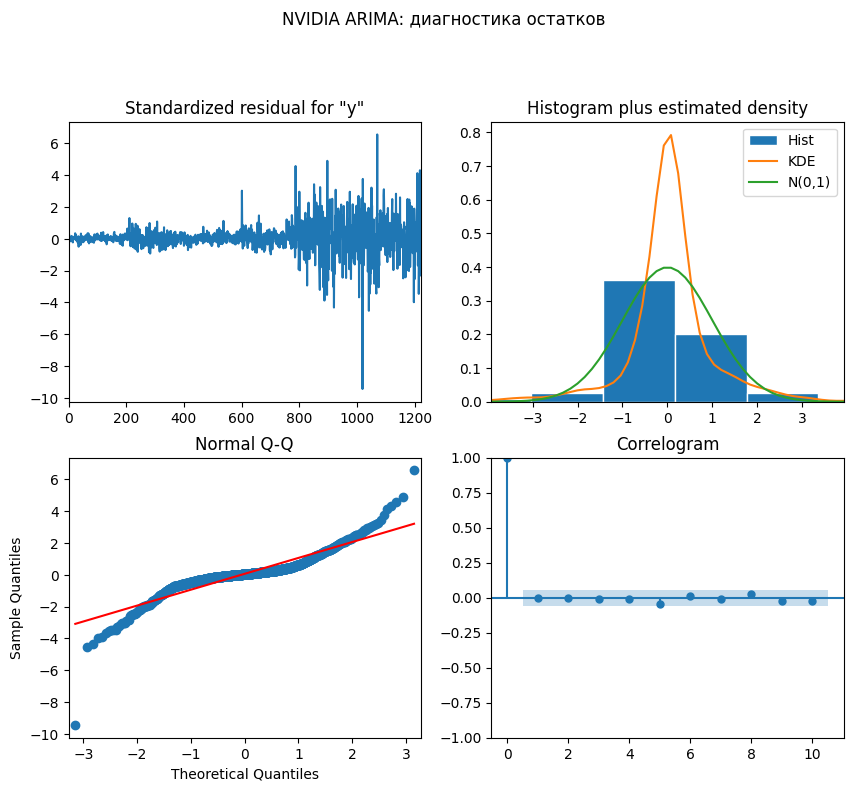

In [579]:
#Остатки ARIMA для NVIDIA
nvda_resid_arima = pd.Series(
    arima_nvda.resid,
    index=nvda_train.index,
    name="resid_arima_nvda"
)

print("NVIDIA ARIMA")
print(
    acorr_ljungbox(
        nvda_resid_arima.dropna(),
        lags=[1, 5, 10],
        return_df=True
    )
)

fig = arima_nvda.plot_diagnostics(figsize=(10, 8))
fig.suptitle("NVIDIA ARIMA: диагностика остатков", y=1.02)
plt.show()

NVIDIA ARIMAX
     lb_stat  lb_pvalue
1   0.000900   0.976069
5   0.506428   0.991886
10  7.570636   0.670696


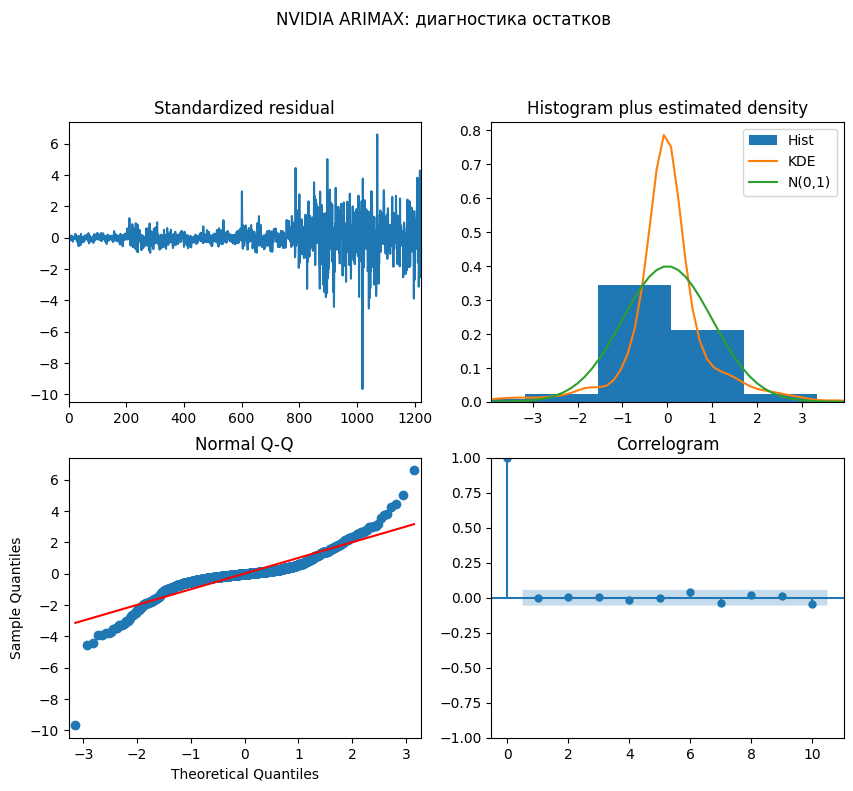

In [580]:
#Остатки ARIMAX для NVIDIA
nvda_resid_arimax = pd.Series(
    arimax_nvda.arima_res_.resid,
    index=y_nvda_train.index,
    name="resid_arimax_nvda"
)

print("NVIDIA ARIMAX")
print(
    acorr_ljungbox(
        nvda_resid_arimax.dropna(),
        lags=[1, 5, 10],
        return_df=True
    )
)

fig = arimax_nvda.plot_diagnostics(figsize=(10, 8))
fig.suptitle("NVIDIA ARIMAX: диагностика остатков", y=1.02)
plt.show()


Для NVIDIA первая разность ряда стационарна, но ACF/PACF показывают заметную автокорреляцию, поэтому была выбрана модель ARIMA(3,1,1). Диагностика остатков (ACF, тест Льюнга–Бокса) показывает отсутствие существенной автокорреляции (p-value > 0.7), то есть модель адекватно описывает временную зависимость в данных.

### 4.3 Метрики прогноза на тестовой выборке

In [581]:
def calc_metrics(y_true, y_pred, name):
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    mape = np.mean(np.abs(err / y_true)) * 100  # в процентах
    
    return pd.Series(
        {"model": name,
         "MAE": mae,
         "RMSE": rmse,
         "MAPE": mape}
    )

metrics = []

# LVMH: базовая ARIMA и ARIMAX
metrics.append(calc_metrics(y_lvmh_test, lvmh_forecast,        "LVMH ARIMA"))
metrics.append(calc_metrics(y_lvmh_test, lvmh_arimax_forecast, "LVMH ARIMAX"))

# NVIDIA: базовая ARIMA и ARIMAX
metrics.append(calc_metrics(y_nvda_test, nvda_forecast,        "NVIDIA ARIMA"))
metrics.append(calc_metrics(y_nvda_test, nvda_arimax_forecast, "NVIDIA ARIMAX"))

metrics_df = pd.DataFrame(metrics).set_index("model")
metrics_df


,MAE,RMSE,MAPE
model,,,
LVMH ARIMA,15.188898,16.753208,2.477773
LVMH ARIMAX,15.855243,17.259284,2.585420
NVIDIA ARIMA,6.067487,6.949053,3.370180
NVIDIA ARIMAX,7.077954,8.087422,3.932139


Использую RMSE как основную метрику для выбора модели, потому что она сильнее штрафует большие ошибки.
Для финансовых рядов (особенно акций) отдельные крупные промахи прогноза могут быть особенно критичными.

### Сравнение качества моделей ARIMA и ARIMAX

Для обеих акций были посчитаны метрики качества прогноза на тестовой выборке
(10 последних наблюдений): MAE, RMSE и MAPE.

- **LVMH**: модель ARIMA показывает немного меньшие ошибки, чем ARIMAX.  
  При этом остатки обеих моделей ведут себя как белый шум, а коэффициенты
  регрессоров в ARIMAX статистически незначимы.  
  **Следовательно, добавление регрессоров не даёт выигрыша в качестве прогноза,
  и в качестве итоговой модели для LVMH выбираю ARIMA.**

- **NVIDIA**: для NVIDIA превосходство ARIMA над ARIMAX более выражено.  
  Остатки обеих моделей не имеют значимой автокорреляции (по тесту Льюнга–Бокса),
  однако модель с регрессорами даёт более высокие ошибки.  
  **Итог: в качестве лучшей модели для NVIDIA также выбирается ARIMA.**



### Итоговый выбор модели

Суммируя результаты:

1. **Диагностика остатков.**  
   У всех моделей остатки ведут себя как приблизительно белый шум:
   тест Льюнга–Бокса не выявляет значимой автокорреляции, на ACF нет
   выраженных пиков. Это говорит о том, что основная временная структура
   (тренды / зависимости между лагами) учтена.

2. **Качество прогноза.**  
   На горизонте 10 дней:

   * для LVMH ARIMAX **хуже** ARIMA по всем метрикам;
   * для NVIDIA ARIMAX даёт лишь микроскопическое улучшение относительно ARIMA.

3. **Регрессоры.**  
   Использованные экзогенные переменные (линейный тренд, понедельники/пятницы,
   праздничный месяц) оказались слишком простыми и слабо связаны
   с динамикой цен, их добавление не даёт ощутимого выигрыша по AIC/BIC
   и по ошибкам прогноза.

### Выбор финальной модели

С учётом результатов диагностики остатков и метрик качества прогноза:

- остатки всех моделей (ARIMA и ARIMAX) не демонстрируют существенной автокорреляции (по ACF и тесту Льюнга–Бокса);
- по MAE/RMSE/MAPE **модели ARIMA без регрессоров стабильно лучше ARIMAX** для обоих активов;
- коэффициенты по добавленным регрессорам в ARIMAX-моделях оказываются статистически незначимыми (p-value ≫ 0.05), что дополнительно подтверждает слабую информативность выбранных X-переменных;
- для NVIDIA ручной перебор по (p, q) показал, что модель **ARIMA(2, 1, 5)** даёт более низкий AIC (5699.6) по сравнению с авто-подбором ARIMA(3, 1, 1) (AIC ≈ 5705.9), при этом остатки также проходят диагностику.

Итого по выбору: для **NVIDIA** финально оставляю **ARIMA(2, 1, 5)**. Для **LVMH** модель ARIMA(0, 1, 0) — это случайное блуждание, её нельзя выбирать как лучшую, она служит базовой точкой отсчёта.

Важно: прогноз строился на дифференцированном ряде, поэтому его нужно вернуть к недифференцированным уровням (накопительная сумма разностей + последнее значение train), иначе сравнение с фактическими уровнями некорректно.

